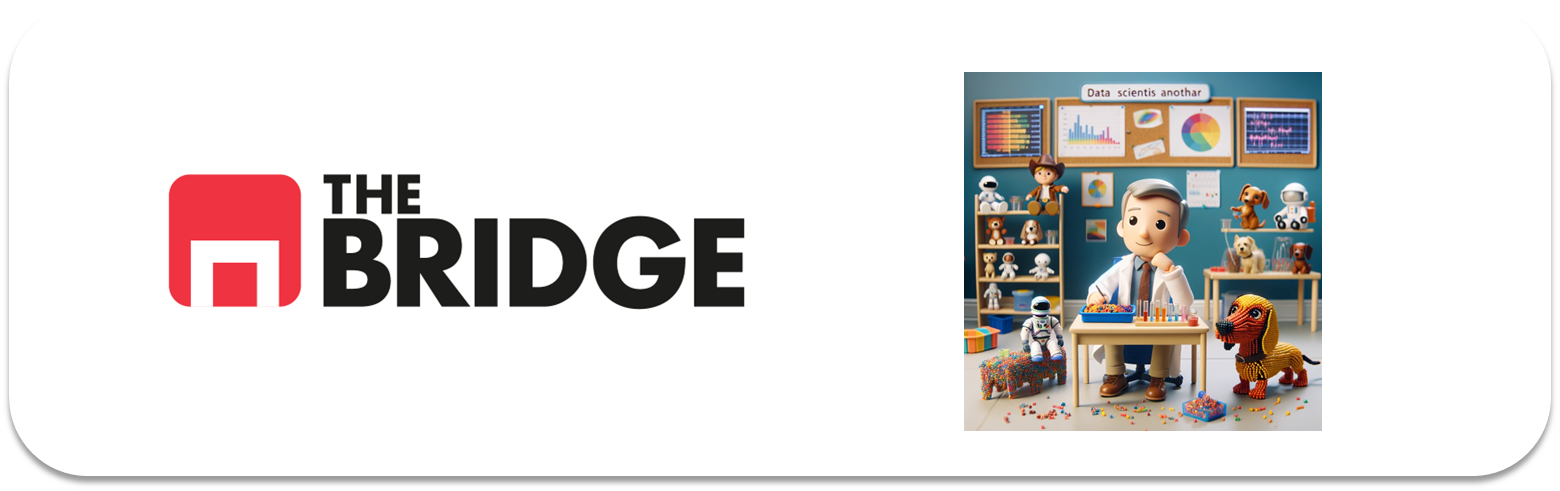

## PRACTICA OBLIGATORIA: **Análisis Univariante**

* La práctica obligatoria de esta unidad consiste en hacer el análisis univariante completo de un dataset con el que acabarás muy familiarizado, el manifiesto de pasajeros del Titanic. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook. Te dejo una que vas a necesitar sí o sí

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.options.mode.copy_on_write = True # CoW por defecto a partir de Pandas 3.0.0

In [3]:
# Cargo todas las funciones del archivo de apoyo

from bootcampviztools import pinta_distribucion_categoricas, plot_categorical_relationship_fin, plot_categorical_numerical_relationship, plot_combined_graphs, grafico_dispersion_con_correlacion, plot_grouped_boxplots, plot_grouped_histograms

### #1 Preparación


### #1.1


Carga en un dataframe los datos del titanic a partir de un dataset de seaborn. Para ello:

* ejecuta ```python sns.get_dataset_names()```
* localiza el nombre que puede ser el adecuado para el ejercicio
* Asigna la salida de ```sns.load_dataset(<nombre_del_dataset>)``` a una variable "df_titanic"

In [4]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [ ]:
# Resolución del ejercicio por Rodrigo Oliver en clase

df_titanic = sns.load_dataset("titanic")

In [8]:
df = df_titanic.copy() # me hago una copia para tener un nombre más corto
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


### #1.2

Muestra una porción del dataset ("df_titanic") y su info general. ¿Hay nulos?

In [10]:
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


### #1.3

Obtén el porcentaje de nulos y decide que hacer con las columnas con nulos y ejecútalo. Además deshazte de la columna "parch" que no la emplearemos.

In [21]:
(df.isna().sum() / len(df) * 100).sort_values(ascending=False) # porcentaje de nulos por variable y ordenado de arriba a abajo

deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
sex             0.000000
pclass          0.000000
survived        0.000000
fare            0.000000
parch           0.000000
sibsp           0.000000
class           0.000000
adult_male      0.000000
who             0.000000
alive           0.000000
alone           0.000000
dtype: float64

In [27]:
df["deck"].value_counts(dropna=False, normalize= True) 

# Analizo los valores de la variable deck y tiene 688 nulos. 
# Con normalize = True lo llevo a porcentaje
# Vemos que deck tiene un volumen de datos inexistente bastante grande.  


deck
NaN    0.772166
C      0.066218
B      0.052750
D      0.037037
E      0.035915
A      0.016835
F      0.014590
G      0.004489
Name: proportion, dtype: float64

In [ ]:
# df["deck"].fillna("UNK") # Los NaN de deck se podrían rellenar con desconocido UNK. 

In [30]:
df.drop(["deck","parch"], axis = 1, inplace = True)
df

,survived,pclass,sex,age,sibsp,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,NaN,1,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [31]:
df[df["embarked"].isna()] # Aquí estoy sacando los valores NaN en embarked. Son dos mujeres que sobrevivieron

,survived,pclass,sex,age,sibsp,fare,embarked,class,who,adult_male,embark_town,alive,alone
61,1,1,female,38.0,0,80.0,NaN,First,woman,False,NaN,yes,True
829,1,1,female,62.0,0,80.0,NaN,First,woman,False,NaN,yes,True


In [33]:
df["embarked"].value_counts(dropna=False, normalize=True) # % de NaN por columna en embarked 

embarked
S      0.722783
C      0.188552
Q      0.086420
NaN    0.002245
Name: proportion, dtype: float64

In [39]:
moda_embarked = df["embarked"].mode()[0] # 

In [40]:
df.loc[df["embarked"].isna(), "embarked"] = moda_embarked 

In [41]:
moda_embark_town = df["embark_town"].mode()[0]

In [42]:
df.loc[df["embark_town"].isna(), "embark_town"] = moda_embark_town

<Axes: >

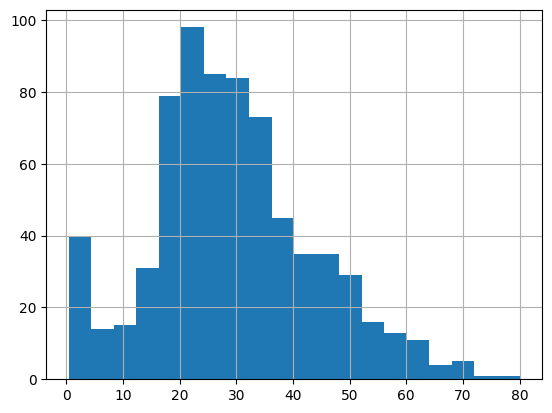

In [51]:
df["age"].hist(bins=20) # Nos permite visualizar relativamente rápido la distribución de edad. 

# La idea es ir valorando la posibilidad de solucionar nuestros nulos de la edad 

<Axes: xlabel='age', ylabel='Count'>

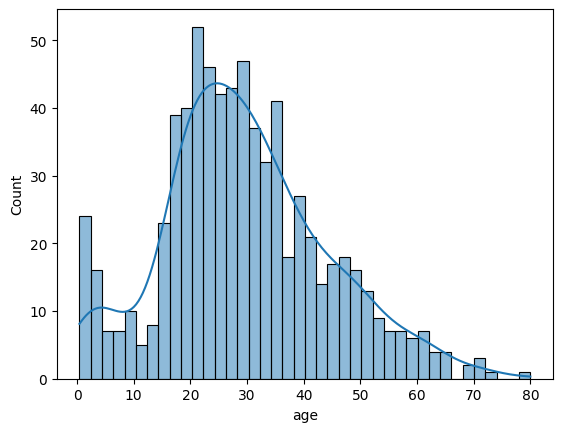

In [50]:
sns.histplot(df["age"], bins = 40, kde = True) # Esto es el histograma de sns con la estimación de densidad del kernel (kde) --> curva de tendencia

In [52]:
df["age"].describe() # Aquí vemos las métricas descriptivas de edad (media, desviación estándar, máx, min, percentiles...)

# El tema de esto es que si normalizo los NaN de la edad con la mediana, podemos provocar que un niño acabe con 28 años de edad. 

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64

In [53]:
df.groupby("who")["age"].median() 

# Mirando la media por cluster de género y edad (hombre, mujer y niño)...
# Vemos cuán lejos están media y mediana de la edad por tipología, para no cometer errores en la normalización

who
child     5.0
man      30.0
woman    30.0
Name: age, dtype: float64

In [54]:
# Columna de flags de imputación 

df["age_imputed"] = df.age.isna()


In [56]:
# Imputo el valor por who en age --> esto me permite imputar mediana de mujeres a los NaN de edad en mujeres y así con bombres y niños

# Máscaras por género

is_woman = df.who == "woman"
is_child = df.who == "child"
is_man = df.who == "man"

# Valores medianos

mediana_woman = df.loc[is_woman,"age"].median()
mediana_child = df.loc[is_child,"age"].median() # No hay chiquillos nulos, pero por si acaso...
mediana_man = df.loc[is_man,"age"].median()

# Imputamos

df.loc[is_woman & df["age_imputed"], "age"] = mediana_woman
df.loc[is_child & df["age_imputed"], "age"] = mediana_child
df.loc[is_man & df["age_imputed"], "age"] = mediana_man

<Axes: xlabel='age', ylabel='Count'>

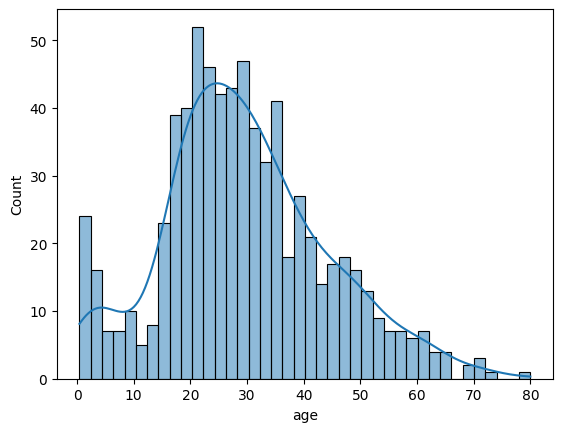

In [59]:
sns.histplot(df["age"][df["age_imputed"] == False], bins = 40, kde = True)

# Si ahora hago el historigrama con edad normalizadas por cluster, la curva cambia
# Estoy sacando de la ecuación las edades imputadas

In [61]:
df.info() # Aquí ya no tengo valores nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   fare         891 non-null    float64 
 6   embarked     891 non-null    object  
 7   class        891 non-null    category
 8   who          891 non-null    object  
 9   adult_male   891 non-null    bool    
 10  embark_town  891 non-null    object  
 11  alive        891 non-null    object  
 12  alone        891 non-null    bool    
 13  age_imputed  891 non-null    bool    
dtypes: bool(3), category(1), float64(2), int64(3), object(5)
memory usage: 73.3+ KB


### #1.4
Sobre el dataset "limpio". Rellena la tabla de descripción (muy breve) de lo que es cada columna en función de su nombre y los valores. Para ayudarte:
* Se trata del dataset que reune lo más parecido a un manifiesto de supervivientes y fallecidos en el viaje.
* sibsp: Es el numero de familiares que viajan con la persona indicada en el manifiesto (lista de pasajeros)
* embarked: Es la incial de la letra de la ciudad donde embarcó la persona.


| Columna/Variable | Descripción |
| ---------------- | ----------- |
| survived         | Indica si el pasajero sobrevivió (1) o no (0) |
| pclass           | Clase del pasaje (1ª, 2ª, 3ª) |
| sex              | Género del pasajero |
| age              | Edad del pasajero |
| sibsp            | Es el numero de familiares que viajan con el pasajero indicado en el manifiesto (lista de pasajeros) |
| parch            | Número de padres/hijos a bordo |
| fare             | Tarifa pagada por el pasajero |
| embarked         | Es la inicial de la ciudad donde embarcó el pasajero (C = Cherbourg, Q = Queenstown, S = Southampton) |
| class            | Clase del pasaje como categoría (Primera, Segunda, Tercera) |
| who              | Categoría del pasajero (hombre, mujer, niño) |
| adult_male       | Booleano que indica si el pasajero es un hombre adulto |
| deck             | Cubierta del barco donde se alojaba el pasajero |
| embark_town      | Ciudad de embarque: Cherbourg, Queenstown, Southampton  |
| alive            | Indica si el pasajero está vivo ('yes') o muerto ('no') |
| alone            | Booleano que indica si el pasajero viajaba solo |

### #1.5

Busca en internet las tres ciudades que visitó el Titanic antes de poner rumbo a su destino y llegar a alta mar. Cambia las iniciales por esos valores.

In [ ]:
# Esto ya está hecho :-) 

### #2 Análisis

Sabiendo que el objetivo de nuestro análisis es hacer un estudio de la superviviencia y mortalidad en el viaje... Haz un análisis univariante completo y ordenado de las siguientes variables:
["alive","who","age","fare","class","embarked","alone"]
Nota: Si quieres añadir más, perfecto.

Separa el análisis en categóricas (incluyendo binarias) y numéricas. Muestra valores, gráficas y conclusiones/observaciones (2 o 3 por variable)

In [62]:
lista_variables = ["alive","who","age","fare","class","embarked","alone","sex"]

In [63]:
# Primero dividir las variables por tipo, usando la función que programamos en los ejercicios

def card_tipo(df, umbral_categoria = 10, umbral_continua = 30):
    # Primera parte: Preparo el dataset con cardinalidades, % variación cardinalidad, y tipos
    df_temp = pd.DataFrame([df.nunique(), df.nunique()/len(df) * 100, df.dtypes]) # Cardinaliad y porcentaje de variación de cardinalidad
    df_temp = df_temp.T # Como nos da los valores de las columnas en columnas, y quiero que estas sean filas, la traspongo
    df_temp = df_temp.rename(columns = {0: "Card", 1: "%_Card", 2: "Tipo"}) # Cambio el nombre de la transposición anterior para que tengan más sentido, y uso asignación en vez de inplace = True (esto es arbitrario para el tamaño de este dataset)

    # Corrección para cuando solo tengo un valor
    df_temp.loc[df_temp.Card == 1, "%_Card"] = 0.00

    # Creo la columna de sugerenica de tipo de variable, empiezo considerando todas categóricas pero podría haber empezado por cualquiera, siempre que adapte los filtros siguientes de forma correspondiente
    df_temp["tipo_sugerido"] = "Categorica"
    df_temp.loc[df_temp["Card"] == 2, "tipo_sugerido"] = "Binaria"
    df_temp.loc[df_temp["Card"] >= umbral_categoria, "tipo_sugerido"] = "Numerica discreta"
    df_temp.loc[df_temp["%_Card"] >= umbral_continua, "tipo_sugerido"] = "Numerica continua"

    # Ojo los filtros aplicados cumplen con el enunciado pero no siguen su orden y planteamiento
    return df_temp

In [69]:
df_tipo = card_tipo(df[lista_variables], 10, 25)
df_tipo

,Card,%_Card,Tipo,tipo_sugerido
alive,2,0.224467,object,Binaria
who,3,0.3367,object,Categorica
age,88,9.876543,float64,Numerica discreta
fare,248,27.833895,float64,Numerica continua
class,3,0.3367,category,Categorica
embarked,3,0.3367,object,Categorica
alone,2,0.224467,bool,Binaria
sex,2,0.224467,object,Binaria


In [70]:
categoricas = df_tipo[df_tipo["tipo_sugerido"].isin(["Binaria","Categorica"])].index.to_list()
numericas = df_tipo[df_tipo["tipo_sugerido"].isin(["Numerica discreta","Numerica continua"])].index.to_list()

In [71]:
categoricas

['alive', 'who', 'class', 'embarked', 'alone', 'sex']

In [72]:
numericas

['age', 'fare']

### #2.1 Categóricas

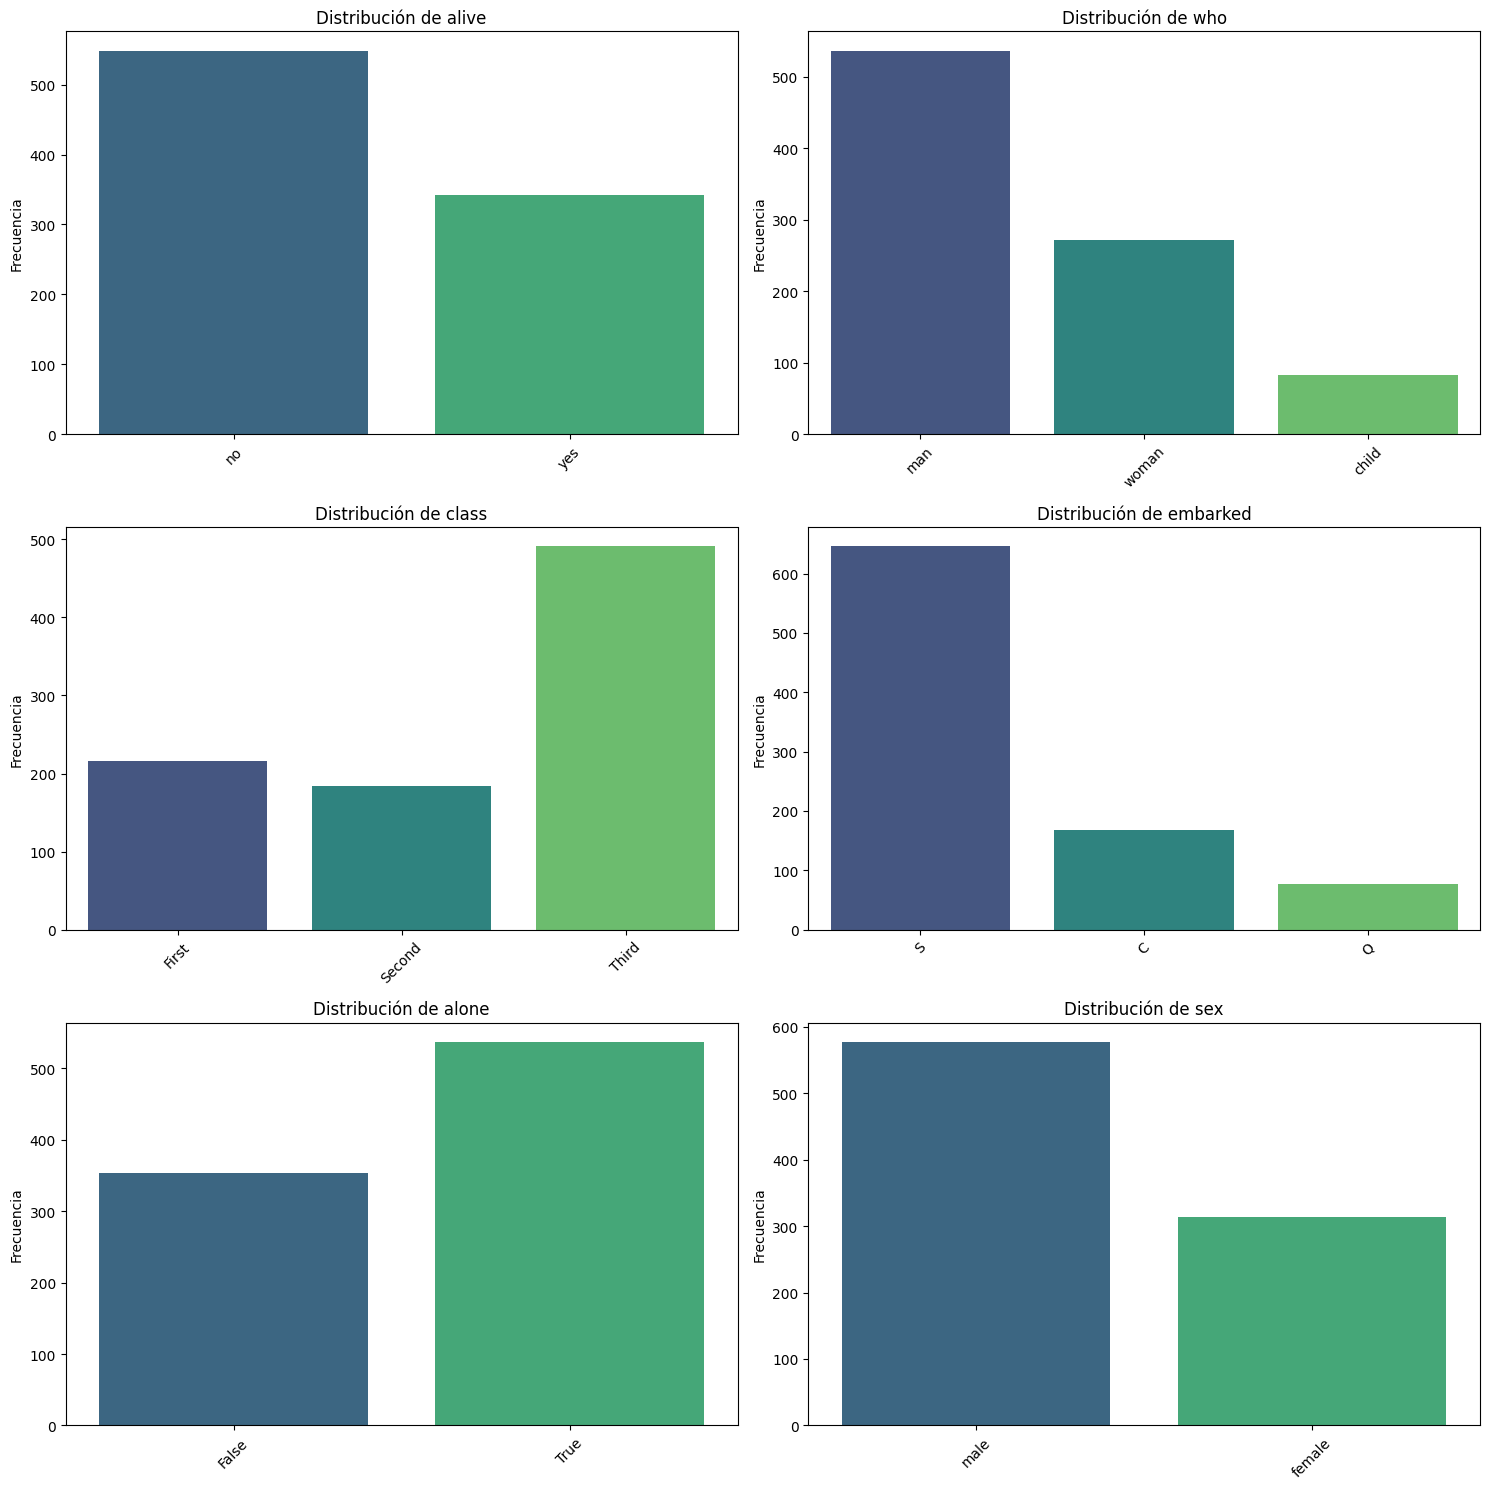

In [74]:
# Empezamos por el análisis frecuencial absoluto utilizando las funciones del workout

pinta_distribucion_categoricas(df, categoricas, mostrar_valores=False)

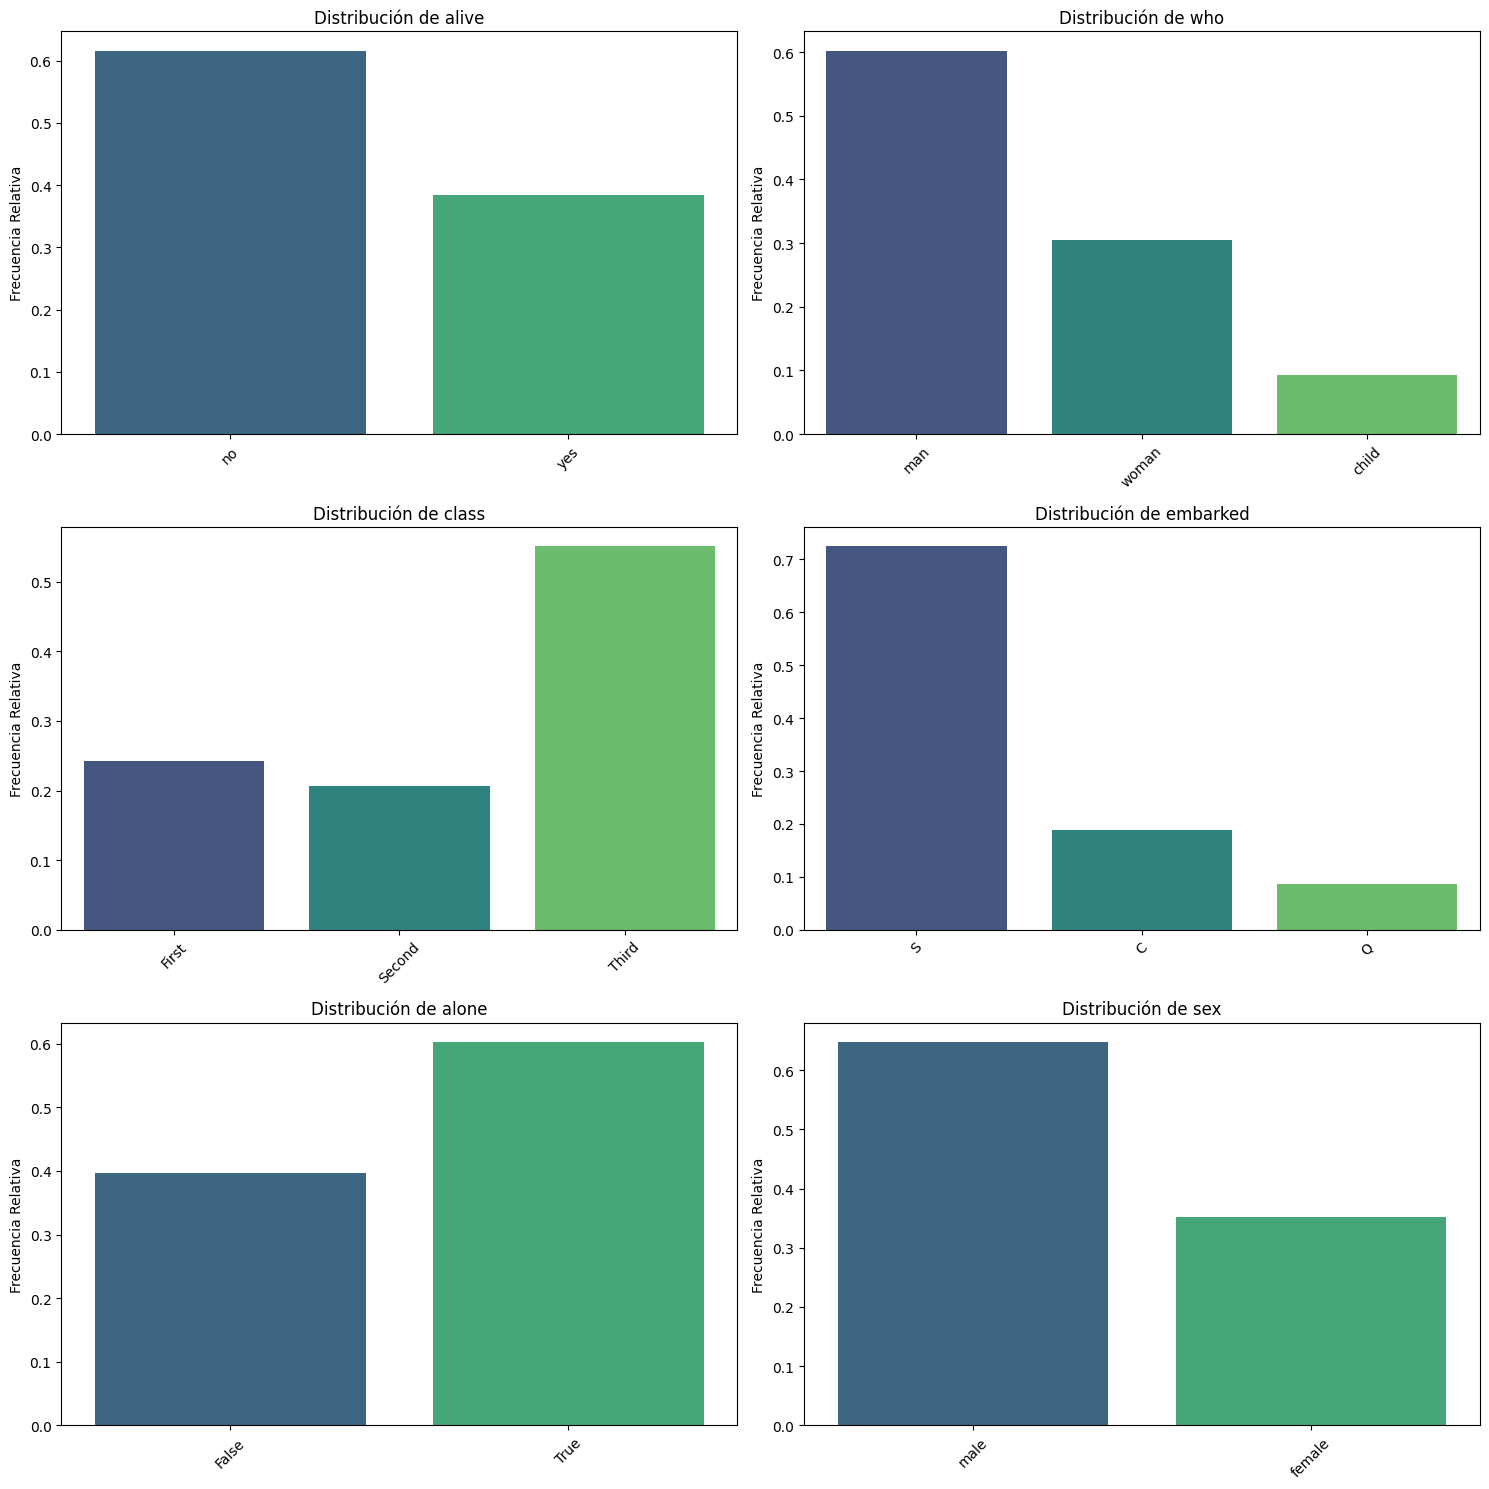

In [76]:
pinta_distribucion_categoricas(df, categoricas, relativa = True, mostrar_valores=False)

#### ***Análisis Univariante Categóricas***:

***alive***:

- Según estos valores el ratio de supervivencia fue casi la mitad que el de mortalidad (38% a 62%). Este dato concuerda con la sensación de que fue un accidente con un alto índice de mortalidad. Estaría bien, si el tiempo lo permite, contrastar con otros datos similares de la época.

***who***

- Esta variable muestra la distinción entre adultos (mujeres y hombres) y niños. Claramente me la apunto para hacer una bivariante con *survived* para saber como se distribuyeron esas muertes y si se mantuvo el patrón (62-38)

***class***

- Habiendo visto la película, estas frecuencias nos pareceran más que normales, claramente había mucho más pasaje de tercera (55%) que de segunda (21%) y de primera (24%). Curiosamente había más de primera que de segunda (por lo menos en este dataset) (Estos curiosamete me los guardo como mensajes de poca prioridad o para dar colorido)

***embarked***

- Por ahora sólo podemos decir que embarcaron principamente en Southampton (72%), un cierto número en Cherboroug (19%) y ya menos en Queenstown (9%).

***alone***

- Según esta variable eran más los pasajeros que viajaban sólos (60%) que los que no (40%), ¿fue un handicap viajar sólo?

***sex***

- Viajaron más hombres que mujeres (65%-35%), y lo interesante vendrá cuando crucemos esta variable con survived o con alive y con who.

#### *Todas las seleccionadas parecen interesantes para hacer un estudio bivariante y multivariante con la variable objetivo **survived/alive**.*

### #2.2 Numéricas

In [78]:
# Valores estadísticos de las numéricas nos da ciertas pistas sobre la distribución posterior:

df[numericas].describe()

,age,fare
count,891.000000,891.000000
mean,29.758889,32.204208
std,13.002570,49.693429
min,0.420000,0.000000
25%,22.000000,7.910400
50%,30.000000,14.454200
75%,35.000000,31.000000
max,80.000000,512.329200


#### Rango intercuartílico de las variables (IQR)

***age***

>IQR = Q3 - Q1 = 35 - 22 = 13
>
>1.5 * IQR = 1.5 * 13 = 19.5
>
>maximum = min(Q3 + 1.5*IQR, max) = min(35 + 19.5, 80) = 54.5
>
>minimum = max(Q1 - 1.5*IQR, min) = max(22 - 19.5, 0.42) = 2.5

***fare***

>IQR = Q3 - Q1 = 31 - 7.9104 = 23.0896
>
>1.5 * IQR = 1.5 * 23.0896 = 34.6344
>
>maximum = min(Q3 + 1.5*IQR, max) = min(31 + 34.6344, 512.3292) = 54.5
>
>minimum = max(Q1 - 1.5*IQR, min) = max(7.9104 - 34.6344, 0) = 2.5

#### Coeficiente de variacion (CV)

Más info: [Wikipedia](https://es.wikipedia.org/wiki/Coeficiente_de_variaci%C3%B3n)

In [79]:
# Obtenemos sus CV con una función

def get_CV(df, columna):
    columna = [columna] if isinstance(columna, str) else columna
    desc = df[columna].describe().T
    return desc["std"] / desc["mean"] * 100

In [80]:
# Le puedo pasar a la función una lista o un string (columna a columna)

get_CV(df, numericas)

# get_CV(df,"age")
# get_CV(df,"fare")

age      43.693063
fare    154.307253
dtype: float64

(2, 2)


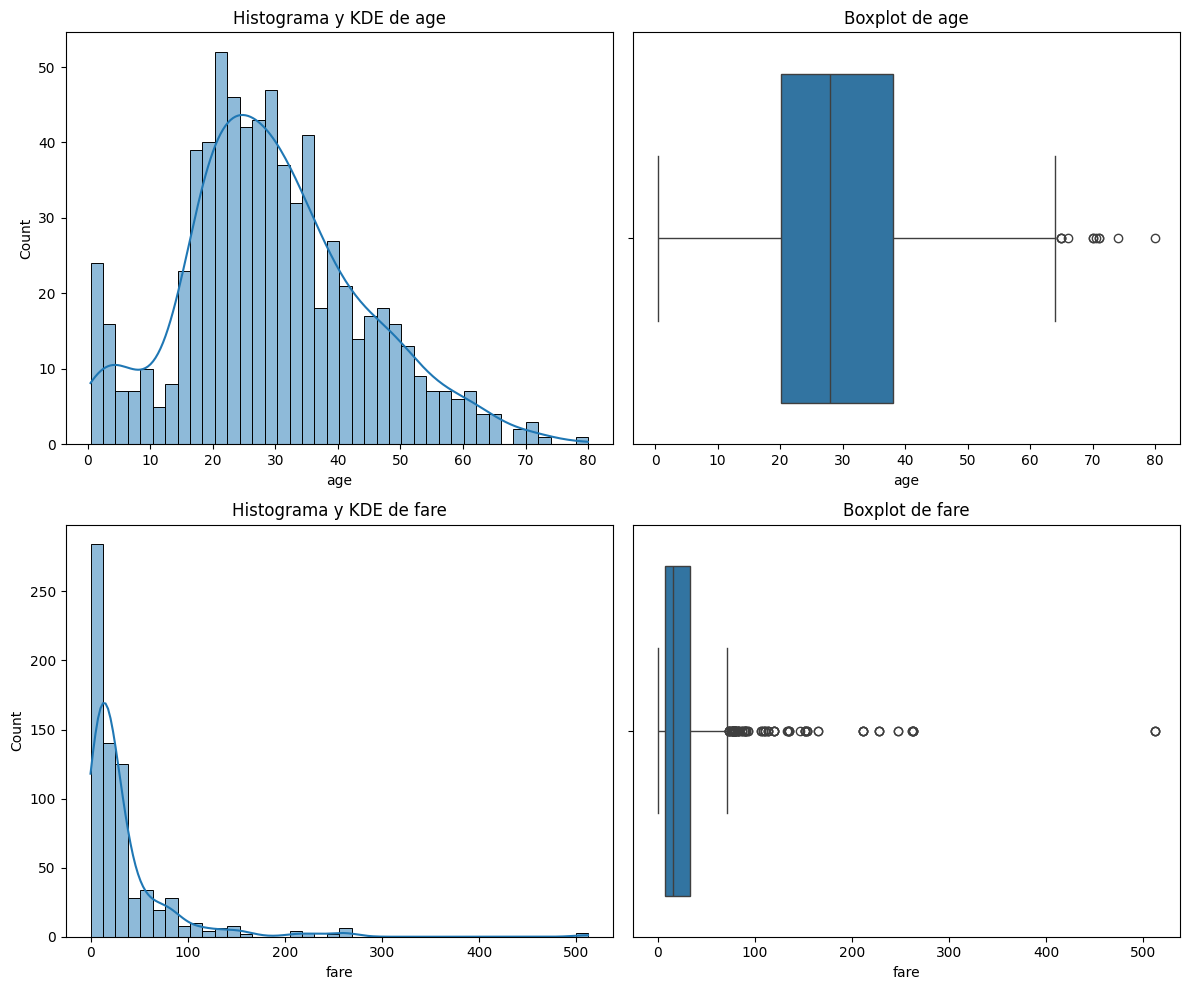

In [84]:
# Ploteamos histogramas y diagramas de caja para las variables numericas

plot_combined_graphs(df[df["age_imputed"] == False], numericas, whisker_width=1.5, bins = 40)